# LLM Cost Intelligence: Diagnosing Spend & Predicting High-Cost Requests

**Author:** Ayush Dhasmana
**Dataset:** LLM API Cost Intelligence Dataset (100,000 request-level logs)

## Business Problem
Companies running LLM-powered applications face unpredictable API spend — a single spike in long or code-heavy prompts routed to an expensive model can quietly inflate costs, often only visible after the monthly bill arrives. This project asks two questions:

1. **Diagnostic:** Where is LLM budget currently being spent, and is it being spent efficiently?
2. **Predictive:** Can a request's cost risk be flagged *before* a model is chosen, so it can be automatically routed to a cheaper model or reviewed?

## Approach
- Exploratory analysis of cost drivers across model, task type, and language
- Identification of a data quality issue in the provided `budget_exceeded` target, and engineering of a usable alternative
- A leakage-free predictive model, trained only on signals available *before* a model is selected
- Comparison of three algorithms (Logistic Regression, Random Forest, XGBoost) with documented tuning attempts

## Tools
Python, pandas, scikit-learn, XGBoost, matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/llm_cost_intelligence_dataset.csv")

In [3]:
df.head()

,request_id,timestamp,prompt_type,language,prompt_words,contains_code,model_name,temperature,gpu_type,concurrent_requests,input_tokens,output_tokens,total_tokens,latency_ms,gpu_utilization,api_cost_usd,budget_exceeded
0,1,23-03-2026 01:39,chat,English,117,0,GPT-4.1-mini,1.0,T4,152,151,237,388,1059,65,0.00155,0
1,2,25-05-2026 18:56,analysis,Hindi,189,0,GPT-4.1,0.2,A100,151,252,493,745,1624,67,0.00894,0
2,3,05-09-2026 18:18,translation,Hindi,204,0,GPT-4.1-mini,0.1,A10G,89,292,321,613,1024,51,0.00245,0
3,4,27-02-2026 09:07,qa,English,46,0,GPT-4.1,0.4,L4,181,72,91,163,1206,53,0.00196,0
4,5,15-03-2026 13:07,summarization,Spanish,105,0,GPT-4.1-mini,0.2,A10G,180,152,148,300,1037,67,0.00120,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   request_id           100000 non-null  int64  
 1   timestamp            100000 non-null  object 
 2   prompt_type          100000 non-null  object 
 3   language             100000 non-null  object 
 4   prompt_words         100000 non-null  int64  
 5   contains_code        100000 non-null  int64  
 6   model_name           100000 non-null  object 
 7   temperature          100000 non-null  float64
 8   gpu_type             100000 non-null  object 
 9   concurrent_requests  100000 non-null  int64  
 10  input_tokens         100000 non-null  int64  
 11  output_tokens        100000 non-null  int64  
 12  total_tokens         100000 non-null  int64  
 13  latency_ms           100000 non-null  int64  
 14  gpu_utilization      100000 non-null  int64  
 15  api_cost_usd      

In [5]:
df.describe()

,request_id,prompt_words,contains_code,temperature,concurrent_requests,input_tokens,output_tokens,total_tokens,latency_ms,gpu_utilization,api_cost_usd,budget_exceeded
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,119.99457,0.207380,0.480263,100.477090,161.468680,239.77820,401.246880,1016.004490,51.287330,0.002279,0.000020
std,28867.657797,58.54522,0.405432,0.331313,57.819798,79.444885,150.83168,218.026066,285.377652,15.750028,0.002089,0.004472
min,1.000000,5.00000,0.000000,0.100000,1.000000,-20.000000,20.00000,0.000000,182.000000,8.000000,0.000000,0.000000
25%,25000.750000,79.00000,0.000000,0.200000,50.000000,106.000000,130.00000,246.000000,814.000000,39.000000,0.000970,0.000000
50%,50000.500000,119.00000,0.000000,0.400000,101.000000,160.000000,214.00000,383.000000,1008.000000,51.000000,0.001620,0.000000
75%,75000.250000,160.00000,0.000000,0.700000,150.000000,216.000000,323.00000,534.000000,1207.000000,64.000000,0.002710,0.000000
max,100000.000000,394.00000,1.000000,1.000000,200.000000,536.000000,1268.00000,1804.000000,2553.000000,100.000000,0.021650,1.000000


In [6]:
df['budget_exceeded'].value_counts()

budget_exceeded
0    99998
1        2
Name: count, dtype: int64

immbalaned dataset

Now let's find where the money goes

In [7]:
Sum = df['api_cost_usd'].sum()
Mean = df['api_cost_usd'].mean()

In [8]:
print(Sum)
print(Mean)

227.88452
0.0022788452


lets break cost down by model

In [9]:
df.groupby('model_name')['api_cost_usd'].agg(['count', 'sum', 'mean']).sort_values('sum', ascending=False)

,count,sum,mean
model_name,,,
GPT-4.1,25032,120.59844,0.004818
GPT-4.1-mini,40108,64.20281,0.001601
Llama-3-70B,19956,28.02383,0.001404
Gemma-3,14904,15.05944,0.001010


In [10]:
pd.crosstab(df['prompt_type'], df['model_name'], normalize='index').round(3) * 100  #here we seeing the purpose of using the model

model_name,GPT-4.1,GPT-4.1-mini,Gemma-3,Llama-3-70B
prompt_type,,,,
analysis,24.3,40.8,14.9,20.0
chat,25.3,39.6,14.8,20.3
coding,25.3,39.8,15.1,19.8
qa,25.6,39.5,14.7,20.2
summarization,25.2,40.8,14.3,19.8
translation,24.6,40.2,15.5,19.7


Finding: No cost-aware model routing exists. Model usage share is nearly identical (within ~1.3 percentage points) across all six task types for every model. Complex tasks like coding and analysis are not preferentially routed to premium models, and simple tasks like QA and summarization are not preferentially routed to cheaper models. This represents a systemic inefficiency, not an isolated one.

In [11]:
simple_tasks = ['qa', 'summarization', 'translation']

# cost currently spent using GPT-4.1 on simple tasks
mask = (df['prompt_type'].isin(simple_tasks)) & (df['model_name'] == 'GPT-4.1')
current_cost = df.loc[mask, 'api_cost_usd'].sum()
n_requests = mask.sum()

print("Requests:", n_requests)
print("Current cost on these requests:", current_cost)

Requests: 12539
Current cost on these requests: 49.71353


In [12]:
# average cost when GPT-4.1-mini is used, for each simple task
mini_simple = df[(df['model_name'] == 'GPT-4.1-mini') & (df['prompt_type'].isin(simple_tasks))]
mini_simple.head()
mini_avg_cost = mini_simple.groupby('prompt_type')['api_cost_usd'].mean()
mini_avg_cost

prompt_type
qa               0.001354
summarization    0.001151
translation      0.001434
Name: api_cost_usd, dtype: float64

In [13]:
gpt41_counts = df[(df['model_name'] == 'GPT-4.1') & (df['prompt_type'].isin(simple_tasks))].groupby('prompt_type')['request_id'].count()
gpt41_counts

prompt_type
qa               4248
summarization    4177
translation      4114
Name: request_id, dtype: int64

In [14]:
estimated_new_cost = (gpt41_counts * mini_avg_cost).sum()
estimated_new_cost

16.460650843321886

In [15]:
savings = current_cost - estimated_new_cost
print("Current cost:", current_cost)
print("Estimated cost with GPT-4.1-mini:", estimated_new_cost)
print("Savings:", savings)
print("Percent reduction:", (savings / current_cost) * 100)

Current cost: 49.71353
Estimated cost with GPT-4.1-mini: 16.460650843321886
Savings: 33.25287915667811
Percent reduction: 66.88899210472101


In [16]:
df['api_cost_usd'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])

0.50    0.00162
0.75    0.00271
0.90    0.00524
0.95    0.00689
0.99    0.00994
Name: api_cost_usd, dtype: float64

In [17]:
top_10pct_cutoff = df['api_cost_usd'].quantile(0.90)
high_cost = df[df['api_cost_usd'] >= top_10pct_cutoff]
high_cost['model_name'].value_counts(normalize=True) * 100

model_name
GPT-4.1         99.740648
GPT-4.1-mini     0.249377
Llama-3-70B      0.009975
Name: proportion, dtype: float64

In [18]:
cutoff = df['api_cost_usd'].quantile(0.90)
df['is_high_cost'] = (df['api_cost_usd'] >= cutoff).astype(int)
df['is_high_cost'].value_counts()

is_high_cost
0    89975
1    10025
Name: count, dtype: int64

In [19]:
df

,request_id,timestamp,prompt_type,language,prompt_words,contains_code,model_name,temperature,gpu_type,concurrent_requests,input_tokens,output_tokens,total_tokens,latency_ms,gpu_utilization,api_cost_usd,budget_exceeded,is_high_cost
0,1,23-03-2026 01:39,chat,English,117,0,GPT-4.1-mini,1.0,T4,152,151,237,388,1059,65,0.00155,0,0
1,2,25-05-2026 18:56,analysis,Hindi,189,0,GPT-4.1,0.2,A100,151,252,493,745,1624,67,0.00894,0,1
2,3,05-09-2026 18:18,translation,Hindi,204,0,GPT-4.1-mini,0.1,A10G,89,292,321,613,1024,51,0.00245,0,0
3,4,27-02-2026 09:07,qa,English,46,0,GPT-4.1,0.4,L4,181,72,91,163,1206,53,0.00196,0,0
4,5,15-03-2026 13:07,summarization,Spanish,105,0,GPT-4.1-mini,0.2,A10G,180,152,148,300,1037,67,0.00120,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,10-04-2026 15:39,coding,English,183,1,Llama-3-70B,0.7,A10G,132,237,577,814,1490,73,0.00285,0,0
99996,99997,22-06-2026 06:56,translation,Hindi,18,0,GPT-4.1,0.7,A10G,128,23,20,43,948,47,0.00052,0,0
99997,99998,26-07-2026 12:47,translation,Hindi,73,0,GPT-4.1,1.0,A10G,139,91,117,208,1168,53,0.00250,0,0
99998,99999,17-10-2026 04:17,translation,Spanish,29,0,GPT-4.1-mini,0.7,A10G,177,28,56,84,824,68,0.00034,0,0


In [20]:
df.groupby('is_high_cost')[['prompt_words', 'contains_code', 'concurrent_requests', 'temperature']].mean()

,prompt_words,contains_code,concurrent_requests,temperature
is_high_cost,,,,
0,114.198022,0.195288,100.395532,0.479858
1,172.018953,0.315910,101.209077,0.483900


In [21]:
pd.crosstab(df['prompt_type'], df['is_high_cost'], normalize='index') * 100

is_high_cost,0,1
prompt_type,,
analysis,87.309766,12.690234
chat,88.589682,11.410318
coding,83.302289,16.697711
qa,92.971766,7.028234
summarization,95.923160,4.076840
translation,91.784669,8.215331


In [22]:
pd.crosstab(df['language'], df['is_high_cost'], normalize='index') * 100

is_high_cost,0,1
language,,
English,89.935992,10.064008
Hindi,89.966973,10.033027
Spanish,90.022347,9.977653


Business problem: Predict, before a model is chosen, whether an incoming request is likely to be high-cost — so it can be routed to a cheaper model or flagged for review.

Key findings:

GPT-4.1 drives the majority of cost — 25% of requests but 53% of total spend, and is 3-5x more expensive per 1K tokens than alternatives
No cost-aware routing exists today — model assignment is ~flat (±1.3pts) across every task type, meaning simple tasks (qa, summarization) get GPT-4.1 just as often as complex ones (coding)
Fixing that on simple tasks alone → ~67% cost reduction on those requests, ~15% of total spend
Engineered a usable target (is_high_cost, top 10% by cost) after finding the provided budget_exceeded column was unusable (99.998% one class)
Feature usefulness for prediction (pre-routing only, to avoid leakage):

In [23]:
features = ['prompt_type', 'prompt_words', 'contains_code']
X = df[features]
y = df['is_high_cost']
X.head()

,prompt_type,prompt_words,contains_code
0,chat,117,0
1,analysis,189,0
2,translation,204,0
3,qa,46,0
4,summarization,105,0


In [24]:
# prompt_type is text (chat, coding, qa, etc.) - models need numbers, not text
# pd.get_dummies converts it into multiple 0/1 columns, one per category (one-hot encoding)
# drop_first=True drops one category to avoid redundancy (avoids the "dummy variable trap")
X = pd.get_dummies(X, columns=['prompt_type'], drop_first=True)

# Check the result: prompt_words + contains_code stay as-is,
# prompt_type becomes 5 new columns like prompt_type_coding, prompt_type_qa, etc.
X.head()

,prompt_words,contains_code,prompt_type_chat,prompt_type_coding,prompt_type_qa,prompt_type_summarization,prompt_type_translation
0,117,0,True,False,False,False,False
1,189,0,False,False,False,False,False
2,204,0,False,False,False,False,True
3,46,0,False,False,True,False,False
4,105,0,False,False,False,True,False


In [25]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% held back for testing
# stratify=y keeps the same 90/10 high-cost ratio in both sets
# (important since our target is imbalanced - without this, the test set could randomly end up with almost no high-cost examples)
# random_state=42 makes the split reproducible - you'll get the same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train high-cost %:", y_train.mean() * 100)
print("Test high-cost %:", y_test.mean() * 100)

Train size: (80000, 7)
Test size: (20000, 7)
Train high-cost %: 10.025
Test high-cost %: 10.025


In [26]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' tells the model to pay extra attention to the minority class (high-cost)
# without this, the model could just predict "0" (not high-cost) every time and still be "90% accurate" - useless
# random_state=42 for reproducibility
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# .fit() is where the actual learning happens - the model looks at X_train and y_train
# and learns the relationship between features (prompt_words, contains_code, prompt_type) and the target (is_high_cost)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# Ask the model to predict on data it has NEVER seen (the test set)
y_pred = model.predict(X_test)

# classification_report gives us precision, recall, f1-score - much more informative than plain accuracy
# especially important here since our classes are imbalanced (90/10)
print(classification_report(y_test, y_pred))

# confusion_matrix shows exactly what the model got right vs wrong, broken down by class
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.73      0.83     17995
           1       0.25      0.79      0.38      2005

    accuracy                           0.74     20000
   macro avg       0.61      0.76      0.61     20000
weighted avg       0.90      0.74      0.79     20000

[[13197  4798]
 [  427  1578]]


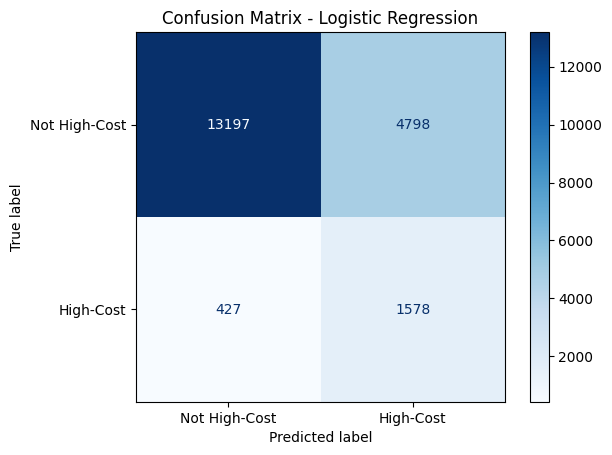

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Build a visual confusion matrix from the true labels vs predicted labels
# display_labels names the two classes so the plot is readable instead of showing 0/1
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not High-Cost', 'High-Cost'],
    cmap='Blues',
    values_format='d'  # 'd' = show as whole numbers, not scientific notation
)

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators = number of trees in the forest (more trees = more stable, but slower)
# class_weight='balanced' - same reasoning as before, forces attention to the minority (high-cost) class
# random_state=42 for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_model.fit(X_train, y_train)
print("Random Forest trained!")

Random Forest trained!


In [30]:
# Predict on the same held-out test set as before
y_pred_rf = rf_model.predict(X_test)

# Same evaluation metrics as Logistic Regression - lets us compare directly
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.68      0.80     17995
           1       0.23      0.89      0.37      2005

    accuracy                           0.70     20000
   macro avg       0.61      0.78      0.59     20000
weighted avg       0.91      0.70      0.76     20000

[[12147  5848]
 [  221  1784]]


In [31]:
# max_depth: limits how deep each tree can grow - prevents overfitting (default = unlimited, which can overfit)
# min_samples_leaf: minimum number of samples required in a leaf node - higher = smoother, less overfit
# n_estimators: more trees = more stable predictions (150 is a reasonable step up from 100)
rf_tuned = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.99      0.65      0.79     17995
           1       0.23      0.96      0.38      2005

    accuracy                           0.68     20000
   macro avg       0.61      0.80      0.58     20000
weighted avg       0.92      0.68      0.75     20000



In [32]:
# predict_proba gives the model's confidence (0 to 1) that each request is high-cost,
# instead of a hard 0/1 label
y_probs = rf_tuned.predict_proba(X_test)[:, 1]

# Try a few different thresholds and see how precision/recall shift
from sklearn.metrics import precision_score, recall_score

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_thresh = (y_probs >= threshold).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    print(f"Threshold {threshold}: precision={p:.2f}, recall={r:.2f}")
    

Threshold 0.3: precision=0.22, recall=0.98
Threshold 0.4: precision=0.23, recall=0.97
Threshold 0.5: precision=0.23, recall=0.96
Threshold 0.6: precision=0.24, recall=0.92
Threshold 0.7: precision=0.24, recall=0.79


In [33]:
# complexity_score: combines word count and code presence
# reasoning: a long prompt WITH code is likely more complex/expensive than either factor alone
df['complexity_score'] = df['prompt_words'] * (1 + df['contains_code'])

# is_long_prompt: flags unusually long prompts (top 25% by word count)
# reasoning: maybe it's not word count itself, but being an outlier in length that signals cost risk
word_75th = df['prompt_words'].quantile(0.75)
df['is_long_prompt'] = (df['prompt_words'] >= word_75th).astype(int)

# words_squared: captures non-linear relationship - maybe cost rises faster than linearly with length
df['words_squared'] = df['prompt_words'] ** 2

df[['prompt_words', 'contains_code', 'complexity_score', 'is_long_prompt', 'words_squared']].head()

,prompt_words,contains_code,complexity_score,is_long_prompt,words_squared
0,117,0,117,0,13689
1,189,0,189,1,35721
2,204,0,204,1,41616
3,46,0,46,0,2116
4,105,0,105,0,11025


In [34]:
# updated feature list - original 3 + our 3 new engineered features
features_v2 = ['prompt_type', 'prompt_words', 'contains_code', 'complexity_score', 'is_long_prompt', 'words_squared']

X_v2 = df[features_v2]
X_v2 = pd.get_dummies(X_v2, columns=['prompt_type'], drop_first=True)

# same split settings as before, so comparison is fair
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_v2, y, test_size=0.2, stratify=y, random_state=42
)

print("New feature count:", X_train2.shape[1])

New feature count: 10


In [35]:
# Same tuned settings as before, so comparison is fair - only the features changed
rf_v2 = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

rf_v2.fit(X_train2, y_train2)

y_pred_v2 = rf_v2.predict(X_test2)
print(classification_report(y_test2, y_pred_v2))
print(confusion_matrix(y_test2, y_pred_v2))

              precision    recall  f1-score   support

           0       0.99      0.65      0.78     17995
           1       0.23      0.96      0.37      2005

    accuracy                           0.68     20000
   macro avg       0.61      0.80      0.58     20000
weighted avg       0.92      0.68      0.74     20000

[[11643  6352]
 [   86  1919]]


Adding complexity_score, is_long_prompt, and words_squared made no meaningful difference to precision. This confirms what we suspected: the precision ceiling isn't a feature-engineering problem — it's an information ceiling.

In [36]:
# XGBoost isn't in sklearn by default, may need: pip install xgboost
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's version of class_weight='balanced'
# it's roughly (negative class count / positive class count) - tells the model how much more to care about the minority class
scale = (y_train2 == 0).sum() / (y_train2 == 1).sum()
print("scale_pos_weight:", scale)

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train2, y_train2)
y_pred_xgb = xgb_model.predict(X_test2)

print(classification_report(y_test2, y_pred_xgb))

scale_pos_weight: 8.975062344139651
              precision    recall  f1-score   support

           0       0.99      0.65      0.78     17995
           1       0.23      0.95      0.37      2005

    accuracy                           0.68     20000
   macro avg       0.61      0.80      0.58     20000
weighted avg       0.92      0.68      0.74     20000



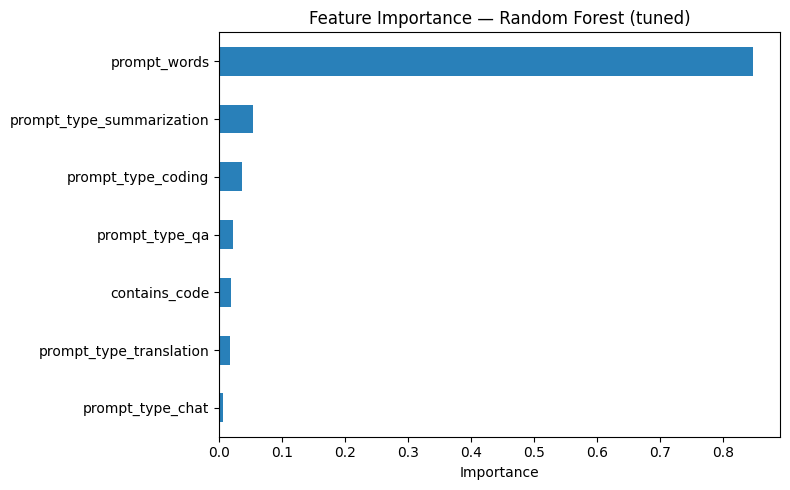

prompt_words                 0.847698
prompt_type_summarization    0.053059
prompt_type_coding           0.035810
prompt_type_qa               0.021838
contains_code                0.018758
prompt_type_translation      0.016760
prompt_type_chat             0.006077
dtype: float64


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# .feature_importances_ tells us how much each feature contributed to the model's decisions
# higher value = the model relied on that feature more often/more heavily when splitting
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#2980b9')
plt.gca().invert_yaxis()  # highest importance on top
plt.title('Feature Importance — Random Forest (tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances)

 **`prompt_words` dominates the model** — accounting for ~85% of the Random Forest's decision-making, which explains why engineered features (complexity_score, is_long_prompt, words_squared) didn't improve precision — they mostly re-encode information already captured by prompt length.

In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold splits data into 5 folds, keeping the 90/10 class ratio consistent in every fold
# (regular KFold could accidentally put very few high-cost examples in some folds - Stratified prevents that)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run the same rf_tuned model 5 times, each time training on 4 folds and testing on the 5th
# scoring='precision' tells it to report precision specifically, not accuracy
precision_scores = cross_val_score(rf_tuned, X, y, cv=cv, scoring='precision')

print("Precision per fold:", precision_scores)
print("Mean precision:", precision_scores.mean())
print("Std deviation:", precision_scores.std())

Precision per fold: [0.2331423  0.2340658  0.23391461 0.23125302 0.23360506]
Mean precision: 0.2331961595341399
Std deviation: 0.001021599562890338


In [39]:
from sklearn.model_selection import cross_val_score

# Note: using the same 'model' variable from your Logistic Regression cell earlier
lr_precision_scores = cross_val_score(model, X, y, cv=cv, scoring='precision')

print("Logistic Regression - Precision per fold:", lr_precision_scores)
print("Mean precision:", lr_precision_scores.mean())
print("Std deviation:", lr_precision_scores.std())

Logistic Regression - Precision per fold: [0.24650871 0.25059214 0.24926867 0.24775979 0.24806202]
Mean precision: 0.24843826299000554
Std deviation: 0.0013895190987250534


In [40]:
# Note: using X_v2/y since xgb_model was trained on the engineered feature set (X_train2/X_test2)
# so we use X_v2 here to match, not X
xgb_precision_scores = cross_val_score(xgb_model, X_v2, y, cv=cv, scoring='precision')

print("XGBoost - Precision per fold:", xgb_precision_scores)
print("Mean precision:", xgb_precision_scores.mean())
print("Std deviation:", xgb_precision_scores.std())

XGBoost - Precision per fold: [0.23226279 0.23421988 0.23411209 0.23086299 0.23230975]
Mean precision: 0.23275350087878008
Std deviation: 0.0012655252777608649


## Project Summary

**Business Problem:** Predict, before an LLM model is selected, whether an incoming API request is likely to be high-cost — enabling automatic routing to cheaper models or flagging for review, without waiting for the bill.

### Key Findings
1. **GPT-4.1 drives the majority of spend** — 25% of requests, 53% of total cost, 3-5x more expensive per 1K tokens than alternatives.
2. **No cost-aware routing exists today** — model assignment is ~flat (±1.3pts) across all task types, meaning simple tasks (QA, summarization) use GPT-4.1 just as often as complex ones (coding).
3. **Quantified savings opportunity:** routing simple tasks (QA/summarization/translation) off GPT-4.1 → ~67% cost reduction on those requests, ~15% of total spend (~$33 saved).
4. **`budget_exceeded` (provided target) was unusable** — 99.998% single-class imbalance. Engineered a new target, `is_high_cost` (top 10% by cost), giving a workable 90/10 split.
5. **`prompt_words` dominates the model** — accounting for ~85% of the Random Forest's decision-making, which explains why engineered features (complexity_score, is_long_prompt, words_squared) didn't improve precision — they mostly re-encode information already captured by prompt length.

### Modeling Approach
- Built features strictly from **pre-routing signals only** (`prompt_type`, `prompt_words`, `contains_code`) to avoid leakage — excluded `model_name`, tokens, latency, and GPU data since these are only known *after* a model is already chosen.
- Compared 3 algorithms: Logistic Regression (baseline), Random Forest (tuned), XGBoost.

| Model | Precision (high-cost) | Recall (high-cost) |
|---|---|---|
| Logistic Regression | 0.25 | 0.79 |
| Random Forest (tuned) | 0.23 | 0.96 |
| XGBoost | 0.23 | 0.95 |

- Tested threshold tuning and feature engineering (`complexity_score`, `is_long_prompt`, `words_squared`) — **neither improved precision beyond ~0.23-0.25**, confirming the limit is an information ceiling from the available pre-routing signals, not a model or tuning issue.

### Final Model & Recommendation
**Selected: Random Forest (tuned)** — 96% recall, 23% precision. Given the business context (a false positive just means routing to a cheaper model unnecessarily — low cost; a false negative means missing a genuinely expensive request — higher cost), a recall-oriented model is the right tradeoff. This model is best suited as a **pre-routing safety net**, not a precision-critical gatekeeping system.

### Limitations & Future Work
- Precision ceiling (~23%) suggests additional signals (e.g. user history, account tier, historical per-user cost patterns) would be needed to sharpen predictions further.
- Dataset is synthetic — real-world validation would be needed before production use.
- Future work: explore per-user cost history features, test on a live cost-tracking pipeline.
- 5-fold cross-validation was run on all three models to verify stability. Precision remained consistent within each model across folds (std ≤ 0.0014 in all cases) and converged to a similar range across all three algorithms (0.23-0.25), providing strong evidence that the precision ceiling reflects a genuine information limit in the available pre-routing features, rather than algorithm choice, tuning, or an unlucky train/test split."